# Task 2: Emotion Recognition from SpeechMFCC features + CNN/LSTM on RAVDESS dataset

In [25]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

## 1. Load Dataset (RAVDESS)Download from Kaggle: `uwrfkaduw/ravdess-emotional-speech-audio` and place folders like `Actor_01/`, `Actor_02/`... inside `./RAVDESS/`.RAVDESS filename code (3rd field) = emotion:01=neutral 02=calm 03=happy 04=sad 05=angry 06=fearful 07=disgust 08=surprised

In [26]:
DATASET_PATH = "RAVDESS" 
emotion_map = {  
    '01': 'neutral', 
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',  
    '05': 'angry', 
    '06': 'fearful',
    '07': 'disgust', 
    '08': 'surprised'
}

file_paths, labels = [], []
for file in glob.glob(os.path.join(DATASET_PATH, "Actor_*", "*.wav")):   
    code = os.path.basename(file).split("-")[2]  
    if code in emotion_map:      
        file_paths.append(file)       
        labels.append(emotion_map[code])
        print(f"Found {len(file_paths)} audio files")
        pd.Series(labels).value_counts()

Found 1 audio files
Found 2 audio files
Found 3 audio files
Found 4 audio files
Found 5 audio files
Found 6 audio files
Found 7 audio files
Found 8 audio files
Found 9 audio files
Found 10 audio files
Found 11 audio files
Found 12 audio files
Found 13 audio files
Found 14 audio files
Found 15 audio files
Found 16 audio files
Found 17 audio files
Found 18 audio files
Found 19 audio files
Found 20 audio files
Found 21 audio files
Found 22 audio files
Found 23 audio files
Found 24 audio files
Found 25 audio files
Found 26 audio files
Found 27 audio files
Found 28 audio files
Found 29 audio files
Found 30 audio files
Found 31 audio files
Found 32 audio files
Found 33 audio files
Found 34 audio files
Found 35 audio files
Found 36 audio files
Found 37 audio files
Found 38 audio files
Found 39 audio files
Found 40 audio files
Found 41 audio files
Found 42 audio files
Found 43 audio files
Found 44 audio files
Found 45 audio files
Found 46 audio files
Found 47 audio files
Found 48 audio files
F

## 2. Extract MFCC Features

In [27]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np


def extract_mfcc(file_path, n_mfcc=40, max_len=174): # 174 = RAVDESS ki average length
    y, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    
    return mfcc.T 
# Visualize one sample  
    if file_paths:   
            sample_mfcc = extract_mfcc(file_paths[0])   
            plt.figure(figsize=(10,4))   
            librosa.display.specshow(sample_mfcc.T, x_axis='time')   
            plt.colorbar()  
            plt.title(f"MFCC - {labels[0]}") 
            plt.show()

#loading the data
X, y = [], []
for fp, lab in zip(file_paths, labels):
    try:
        X.append(extract_mfcc(fp))
        y.append(lab)
    except Exception as e:
        print(f"Skipped {fp}: {e}")

X = np.array(X) 
y = np.array(y)
print("Data Shapes:", X.shape, y.shape)

Data Shapes: (1440, 174, 40) (1440,)


## 3. Encode Labels & Split

In [29]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_cat = to_categorical(y_enc)
num_classes = y_cat.shape[1]
X_train, X_test, y_train, y_test = train_test_split(   
    X, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_enc)
print(X_train.shape, X_test.shape)

(1152, 174, 40) (288, 174, 40)


## 4. Build CNN + LSTM Model

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout, BatchNormalization, MaxPooling1D

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # Keep only this
    Conv1D(128, kernel_size=5, activation='relu'), # Removed input_shape from here
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)                    │ (None, 170, 128)            │          25,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 170, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 85, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 85, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 81, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 81, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 40, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 40, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 175,112 (684.03 KB)

 Trainable params: 174,728 (682.53 KB)

 Non-trainable params: 384 (1.50 KB)

## 5. Train

In [37]:
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit( 
    X_train, y_train,   
    validation_data=(X_test, y_test), 
    epochs=60,  
    batch_size=32, 
    callbacks=[es],
    verbose =1
)

Epoch 1/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8331 - loss: 0.4664 - val_accuracy: 0.6458 - val_loss: 1.3331
Epoch 2/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.8835 - loss: 0.3369 - val_accuracy: 0.6632 - val_loss: 1.1163
Epoch 3/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8903 - loss: 0.3362 - val_accuracy: 0.5521 - val_loss: 1.7668
Epoch 4/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8711 - loss: 0.3707 - val_accuracy: 0.6493 - val_loss: 1.1081
Epoch 5/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9049 - loss: 0.3125 - val_accuracy: 0.6250 - val_loss: 1.3278
Epoch 6/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.8876 - loss: 0.3614 - val_accuracy: 0.6597 - val_loss: 1.1700
Epoch 7/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8860 - loss: 0.3404 - val_accuracy: 0.6042 - val_loss: 1.7410
Epoch 8/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8619 - loss: 0.3786 - val_accuracy: 0.6389 - v

## 6. Training Curves

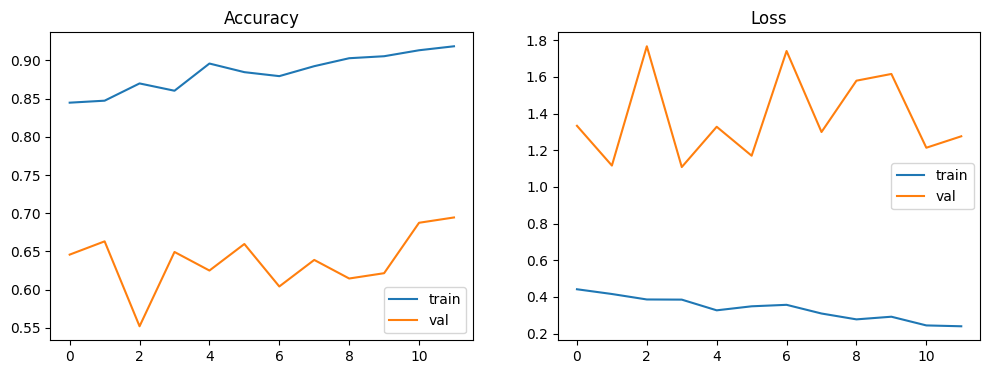

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(history.history['accuracy'],label='train')
ax[0].plot(history.history['val_accuracy'], label='val')
ax[0].set_title('Accuracy'); 
ax[0].legend()
ax[1].plot(history.history['loss'], label='train')
ax[1].plot(history.history['val_loss'], label='val')
ax[1].set_title('Loss');
ax[1].legend()
plt.show()

## 7. Evaluate

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
              precision    recall  f1-score   support

       angry       0.83      0.79      0.81        38
        calm       0.85      0.58      0.69        38
     disgust       0.59      0.84      0.70        38
     fearful       0.58      0.82      0.68        39
       happy       0.75      0.31      0.44        39
     neutral       0.42      0.68      0.52        19
         sad       0.68      0.39      0.50        38
   surprised       0.65      0.79      0.71        39

    accuracy                           0.65       288
   macro avg       0.67      0.65      0.63       288
weighted avg       0.69      0.65      0.64       288



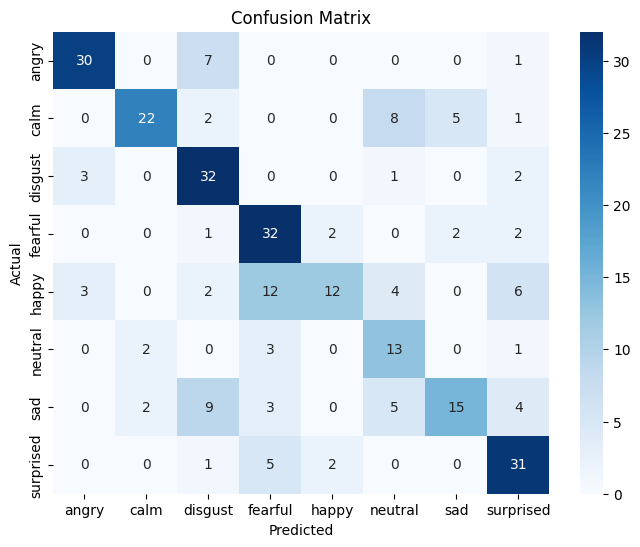

In [39]:
y_pred = model.predict(X_test)
y_pred_labels = le.inverse_transform(np.argmax(y_pred, axis=1))
y_true_labels = le.inverse_transform(np.argmax(y_test, axis=1))
print(classification_report(y_true_labels, y_pred_labels))
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted'); 
plt.ylabel('Actual');
plt.title('Confusion Matrix')
plt.show()

## 8. Save Model

In [34]:
model.save("speech_emotion_model.keras")
print("Model saved.")

Model saved.


In [35]:
pip install sounddevice

Note: you may need to restart the kernel to use updated packages.


In [40]:
import sounddevice as sd
from scipy.io.wavfile import write
import librosa

def predict_emotion():
    print("Recoring will start in 3 seconds")
    fs = 22050 # Sample rate
    seconds = 3 
    #Recording the sound
    sd.wait()
    myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
    sd.wait()
    write('test.wav', fs, myrecording)
    print("Recording complete")
    
    # MFCC Extraction
    mfcc = extract_mfcc('test.wav')
    mfcc = np.expand_dims(mfcc, axis=0) # shape بنانی ہے (1, 174, 40)
    
    # 3. Prediction 
    prediction = model.predict(mfcc)
    predicted_emotion = le.inverse_transform([np.argmax(prediction)])
    
    print(f" Your emotion is:{predicted_emotion[0]}")
predict_emotion()

Recoring will start in 3 seconds
Recording complete
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
 Your emotion is:fearful
